# CNN - Clasificación de Neumonía

Clases: `0 = NORMAL`, `1 = PNEUMONIA`

## 1. Setup e imports

In [5]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler

# Permite importar transforms desde data_prep/
ROOT = Path("__file__").resolve().parent.parent
sys.path.insert(0, str(ROOT))
from data_prep.transforms import eval_transforms, train_transforms

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Usando device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Matplotlib is building the font cache; this may take a moment.


Usando device: mps


## 2. Dataset y DataLoaders

In [17]:
class ChestXRayDataset(Dataset):
    def __init__(self, records, root, transform=None):
        self.records = records
        self.root = Path(root)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = Image.open(self.root / rec["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, rec["label"]


SPLITS_PATH = ROOT / "data_prep" / "splits.json"
with open(SPLITS_PATH) as f:
    splits = json.load(f)

train_ds = ChestXRayDataset(splits["train"], ROOT, transform=train_transforms)
val_ds   = ChestXRayDataset(splits["val"],   ROOT, transform=eval_transforms)
test_ds  = ChestXRayDataset(splits["test"],  ROOT, transform=eval_transforms)

# WeightedRandomSampler para compensar el desbalance 73% PNEUMONIA / 27% NORMAL
train_labels = [r["label"] for r in splits["train"]]
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

print(f"Train: {len(train_ds)} imágenes | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Distribución train — NORMAL: {class_counts[0]} | PNEUMONIA: {class_counts[1]}")

Train: 4711 imágenes | Val: 521 | Test: 624
Distribución train — NORMAL: 1215 | PNEUMONIA: 3496


## 3. Definición del modelo

In [ ]:
class ConvBlock(nn.Module):
    """Bloque doble de convoluciones estilo VGG con BatchNorm."""

    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.BatchNorm2d(out_ch),
        )

    def forward(self, x):
        return self.block(x)


class CnnBaseline(nn.Module):
    def __init__(self, num_classes=2, dropout=0.4):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32),
            ConvBlock(32,  64),
            ConvBlock(64, 128),
        )
        # GlobalAveragePooling: colapsa HxW → 1x1, reduce parámetros vs Flatten
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)


model = CnnBaseline().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")
print(model)

## 4. Configuración del entrenamiento

In [ ]:
# class_weight refuerza el costo de equivocarse en la clase minoritaria (NORMAL)
cw = torch.tensor(class_weights / class_weights.sum() * 2, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=cw)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Reduce lr a la mitad si val_loss no mejora en 3 épocas
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

EPOCHS = 20
MODELS_DIR = ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
CHECKPOINT = MODELS_DIR / "baseline_best.pt"

## 5. Loop de entrenamiento

In [12]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            total += len(labels)
    return total_loss / total, correct / total


history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss,   val_acc   = run_epoch(val_loader,   training=False)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT)
        tag = " ← mejor"
    else:
        tag = ""

    print(
        f"Época {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}{tag}"
    )

Época 01/20 | train_loss=0.2446 train_acc=0.883 | val_loss=0.5797 val_acc=0.795 ← mejor
Época 02/20 | train_loss=0.1821 train_acc=0.902 | val_loss=0.2275 val_acc=0.914 ← mejor
Época 03/20 | train_loss=0.1550 train_acc=0.915 | val_loss=0.2140 val_acc=0.925 ← mejor
Época 04/20 | train_loss=0.1412 train_acc=0.927 | val_loss=0.3968 val_acc=0.860
Época 05/20 | train_loss=0.1116 train_acc=0.941 | val_loss=0.7579 val_acc=0.768
Época 06/20 | train_loss=0.1105 train_acc=0.943 | val_loss=0.2871 val_acc=0.877
Época 07/20 | train_loss=0.1056 train_acc=0.942 | val_loss=0.1836 val_acc=0.929 ← mejor
Época 08/20 | train_loss=0.0843 train_acc=0.958 | val_loss=0.2998 val_acc=0.896
Época 09/20 | train_loss=0.1044 train_acc=0.949 | val_loss=0.2344 val_acc=0.914
Época 10/20 | train_loss=0.1019 train_acc=0.947 | val_loss=0.1502 val_acc=0.940 ← mejor
Época 11/20 | train_loss=0.0869 train_acc=0.956 | val_loss=0.1850 val_acc=0.939
Época 12/20 | train_loss=0.0875 train_acc=0.954 | val_loss=0.1146 val_acc=0.956 

## 6. Curvas de entrenamiento

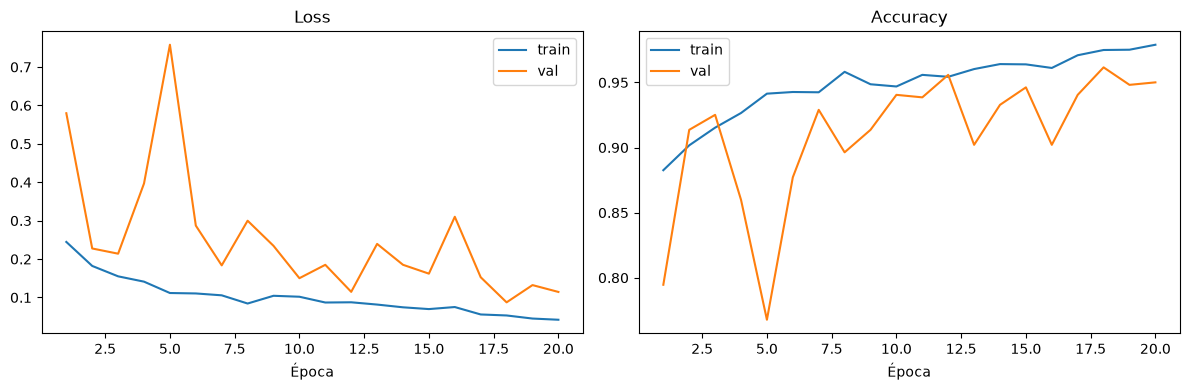

Mejor val_loss: 0.0873


In [18]:
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history["train_loss"], label="train")
ax1.plot(epochs_range, history["val_loss"],   label="val")
ax1.set_title("Loss")
ax1.set_xlabel("Época")
ax1.legend()

ax2.plot(epochs_range, history["train_acc"], label="train")
ax2.plot(epochs_range, history["val_acc"],   label="val")
ax2.set_title("Accuracy")
ax2.set_xlabel("Época")
ax2.legend()

plt.tight_layout()
plt.savefig(ROOT / "training" / "baseline_curves.png", dpi=150)
plt.show()
print(f"Mejor val_loss: {best_val_loss:.4f}")

## 7. Evaluación formal sobre el conjunto de test

Se carga el mejor checkpoint guardado durante el entrenamiento.

In [19]:
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

              precision    recall  f1-score   support

      NORMAL       0.95      0.61      0.74       234
   PNEUMONIA       0.81      0.98      0.89       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



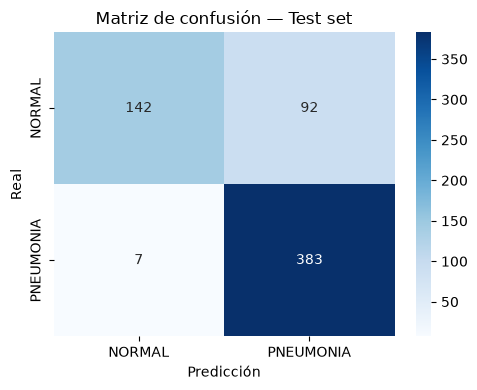

In [20]:
# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"],
    ax=ax,
)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — Test set")
plt.tight_layout()
plt.savefig(ROOT / "training" / "baseline_confusion.png", dpi=150)
plt.show()

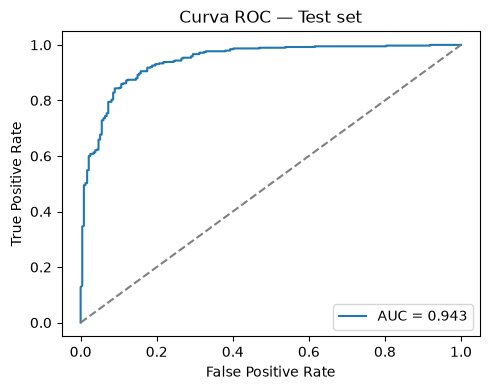

ROC-AUC: 0.9427


In [21]:
# Curva ROC
auc = roc_auc_score(all_labels, all_probs)
fpr, tpr, _ = roc_curve(all_labels, all_probs)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Test set")
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / "training" / "baseline_roc.png", dpi=150)
plt.show()
print(f"ROC-AUC: {auc:.4f}")